# Retail Sales Forecasting - Rossmann Store Sales

Predicting daily store sales using historical data, feature engineering, and Random Forest regression.

In [1]:
import pandas as pd

## 1. Data Loading

In [2]:
train = pd.read_csv('train.csv', low_memory=False)
store = pd.read_csv('store.csv')

In [3]:
print(train.shape)
print(train.head())
print(train.info())

(1017209, 9)
   Store  DayOfWeek        Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5  2015-07-31   5263        555     1      1            0   
1      2          5  2015-07-31   6064        625     1      1            0   
2      3          5  2015-07-31   8314        821     1      1            0   
3      4          5  2015-07-31  13995       1498     1      1            0   
4      5          5  2015-07-31   4822        559     1      1            0   

   SchoolHoliday  
0              1  
1              1  
2              1  
3              1  
4              1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers  

## 2. Data Cleaning

In [4]:
print(store.isnull().sum())

Store                          0
StoreType                      0
Assortment                     0
CompetitionDistance            3
CompetitionOpenSinceMonth    354
CompetitionOpenSinceYear     354
Promo2                         0
Promo2SinceWeek              544
Promo2SinceYear              544
PromoInterval                544
dtype: int64


In [5]:
store['CompetitionDistance'] = store['CompetitionDistance'].fillna(store['CompetitionDistance'].median())
store['CompetitionOpenSinceMonth'] = store['CompetitionOpenSinceMonth'].fillna(0)
store['CompetitionOpenSinceYear'] = store['CompetitionOpenSinceYear'].fillna(0)
store['Promo2SinceWeek'] = store['Promo2SinceWeek'].fillna(0)
store['Promo2SinceYear'] = store['Promo2SinceYear'].fillna(0)
store['PromoInterval'] = store['PromoInterval'].fillna('None')

## 3. Merging Datasets

In [6]:
df = pd.merge(train, store, on='Store', how='left')

In [7]:
print(df.shape)
df.head()

(1017209, 18)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,0.0,0.0,None
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,0.0,0.0,None
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,0.0,0.0,None


## 4. Date Feature Extraction

In [8]:
df['Date'] = pd.to_datetime(df['Date'])

In [9]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df['WeekOfYear'] = df['Date'].dt.isocalendar().week

## 5. Exploratory Data Analysis (EDA)

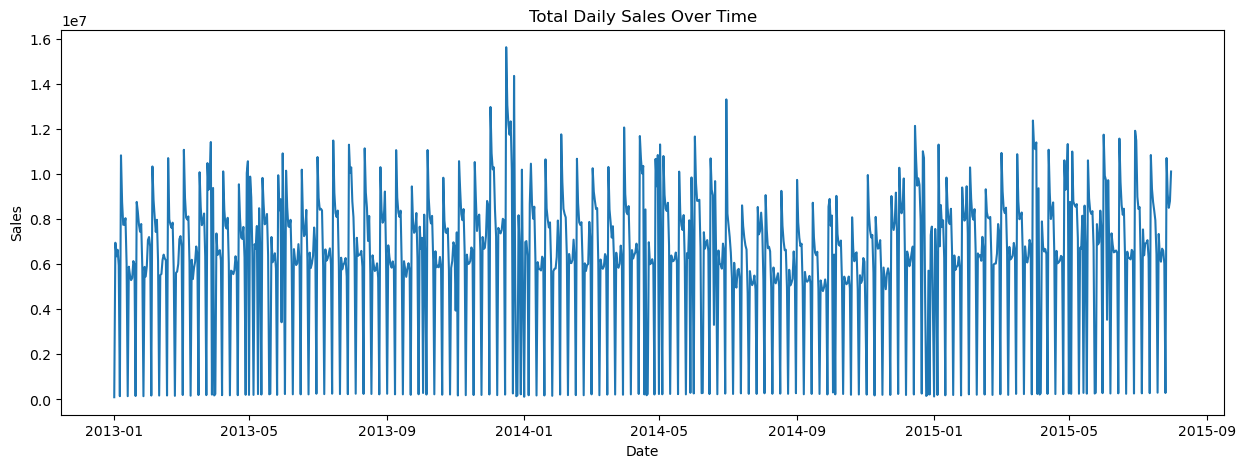

In [10]:
import matplotlib.pyplot as plt

daily_sales = df.groupby('Date')['Sales'].sum()

plt.figure(figsize=(15,5))
plt.plot(daily_sales)
plt.title('Total Daily Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.show()

In [11]:
avg_sales_by_day = df.groupby('DayOfWeek')['Sales'].mean()
print(avg_sales_by_day)

DayOfWeek
1    7809.044510
2    7005.244467
3    6555.884138
4    6247.575913
5    6723.274305
6    5847.562599
7     204.183189
Name: Sales, dtype: float64


In [12]:
sunday_data = df[df['DayOfWeek'] == 7]
print(sunday_data['Open'].value_counts())

Open
0    141137
1      3593
Name: count, dtype: int64


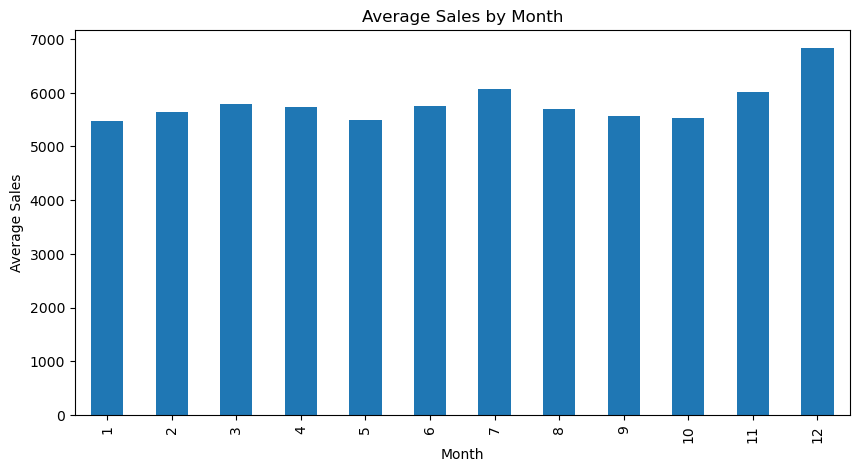

In [13]:
monthly_sales = df.groupby('Month')['Sales'].mean()

plt.figure(figsize=(10,5))
monthly_sales.plot(kind='bar')
plt.title('Average Sales by Month')
plt.xlabel('Month')
plt.ylabel('Average Sales')
plt.show()

In [14]:
promo_sales = df.groupby('Promo')['Sales'].mean()
print(promo_sales)

Promo
0    4406.050805
1    7991.152046
Name: Sales, dtype: float64


In [15]:
holiday_sales = df.groupby('StateHoliday')['Sales'].mean()
print(holiday_sales)

StateHoliday
0    5947.483893
a     290.735686
b     214.311510
c     168.733171
Name: Sales, dtype: float64


In [16]:
df[df['StateHoliday'] != '0']['Open'].value_counts()

Open
0    30140
1      910
Name: count, dtype: int64

# 6. Feature Engineering

In [17]:
df = df[df['Open'] == 1]
print(df.shape)

(844392, 22)


In [18]:
df = df.sort_values(['Store', 'Date'])
df['Sales_Lag1'] = df.groupby('Store')['Sales'].shift(1)

In [19]:
df['Sales_Lag7'] = df.groupby('Store')['Sales'].shift(7)

In [20]:
df['Sales_RollingMean7'] = df.groupby('Store')['Sales'].transform(lambda x: x.shift(1).rolling(window=7).mean())

In [21]:
df[['Store', 'Date', 'Sales', 'Sales_Lag1', 'Sales_Lag7', 'Sales_RollingMean7']].head(15)


,Store,Date,Sales,Sales_Lag1,Sales_Lag7,Sales_RollingMean7
1014980,1,2013-01-02,5530,NaN,NaN,NaN
1013865,1,2013-01-03,4327,5530.0,NaN,NaN
1012750,1,2013-01-04,4486,4327.0,NaN,NaN
1011635,1,2013-01-05,4997,4486.0,NaN,NaN
1009405,1,2013-01-07,7176,4997.0,NaN,NaN
1008290,1,2013-01-08,5580,7176.0,NaN,NaN
1007175,1,2013-01-09,5471,5580.0,NaN,NaN
1006060,1,2013-01-10,4892,5471.0,5530.0,5366.714286
1004945,1,2013-01-11,4881,4892.0,4327.0,5275.571429
1003830,1,2013-01-12,4952,4881.0,4486.0,5354.714286


In [22]:
df = df.dropna(subset=['Sales_Lag1', 'Sales_Lag7', 'Sales_RollingMean7'])
print(df.shape)

(836587, 25)


In [23]:
df = pd.get_dummies(df, columns=['StoreType', 'Assortment', 'StateHoliday'], drop_first=True)

In [24]:
print(df.shape)
df.head()

(836587, 30)


,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,...,Sales_Lag7,Sales_RollingMean7,StoreType_b,StoreType_c,StoreType_d,Assortment_b,Assortment_c,StateHoliday_a,StateHoliday_b,StateHoliday_c
1006060,1,4,2013-01-10,4892,615,1,1,1,1270.0,9.0,...,5530.0,5366.714286,False,True,False,False,False,False,False,False
1004945,1,5,2013-01-11,4881,592,1,1,1,1270.0,9.0,...,4327.0,5275.571429,False,True,False,False,False,False,False,False
1003830,1,6,2013-01-12,4952,646,1,0,0,1270.0,9.0,...,4486.0,5354.714286,False,True,False,False,False,False,False,False
1001600,1,1,2013-01-14,4717,616,1,0,0,1270.0,9.0,...,4997.0,5421.285714,False,True,False,False,False,False,False,False
1000485,1,2,2013-01-15,3900,512,1,0,0,1270.0,9.0,...,7176.0,5381.285714,False,True,False,False,False,False,False,False


## 7. Train-Test Split

In [25]:
df = df.sort_values('Date')

split_date = df['Date'].max() - pd.Timedelta(days=42)

train_data = df[df['Date'] <= split_date]
test_data = df[df['Date'] > split_date]

print(train_data.shape)
print(test_data.shape)

(796305, 30)
(40282, 30)


In [26]:
features = ['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 
            'Promo2', 'Year', 'Month', 'Day', 'WeekOfYear', 
            'Sales_Lag1', 'Sales_Lag7', 'Sales_RollingMean7']

X_train = train_data[features]
y_train = train_data['Sales']

X_test = test_data[features]
y_test = test_data['Sales']

In [27]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(796305, 13) (796305,)
(40282, 13) (40282,)


## 8. Model Training

In [28]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 9. Model Evaluation

In [29]:
predictions = model.predict(X_test)
print(predictions[:10])

[ 4299.34  5911.21  6753.4   4762.48  5425.26  4686.55 13885.46  5989.7
  4749.95  6468.29]


In [30]:
comparison = pd.DataFrame({'Actual': y_test.values[:10], 'Predicted': predictions[:10]})
print(comparison)

   Actual  Predicted
0    4688    4299.34
1    6251    5911.21
2    8744    6753.40
3    7341    4762.48
4    7041    5425.26
5    4499    4686.55
6   14643   13885.46
7    5671    5989.70
8    6429    4749.95
9    5728    6468.29


In [31]:
from sklearn.metrics import mean_squared_error, mean_absolute_percentage_error
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, predictions))
mape = mean_absolute_percentage_error(y_test, predictions)

print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape*100:.2f}%")

RMSE: 1002.73
MAPE: 10.40%


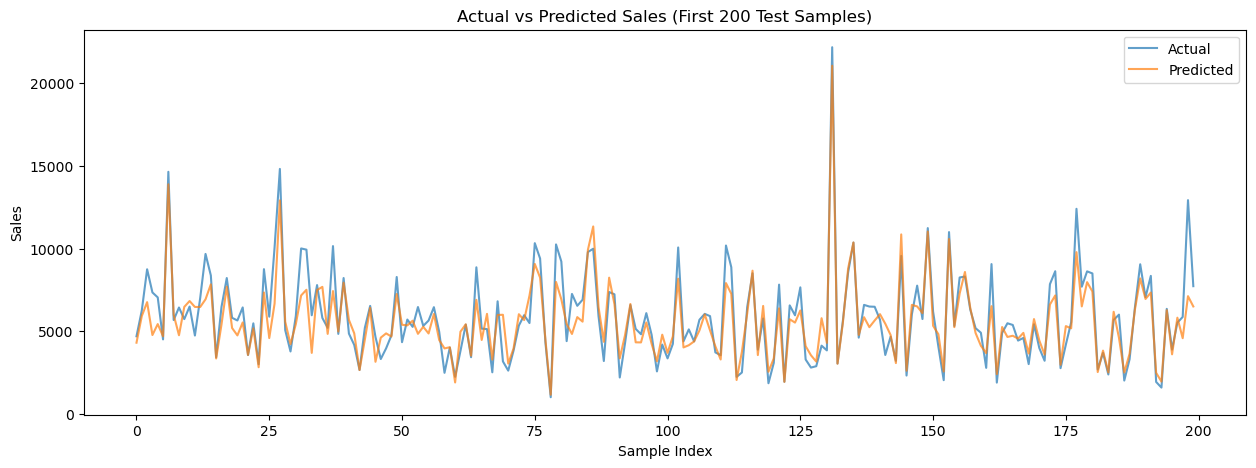

In [32]:
plt.figure(figsize=(15,5))
plt.plot(y_test.values[:200], label='Actual', alpha=0.7)
plt.plot(predictions[:200], label='Predicted', alpha=0.7)
plt.legend()
plt.title('Actual vs Predicted Sales (First 200 Test Samples)')
plt.xlabel('Sample Index')
plt.ylabel('Sales')
plt.show()

## 10. Feature Importance

In [33]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

                Feature  Importance
10           Sales_Lag1    0.592782
12   Sales_RollingMean7    0.103049
1             DayOfWeek    0.101911
2                 Promo    0.057817
8                   Day    0.031566
11           Sales_Lag7    0.028807
4   CompetitionDistance    0.026233
0                 Store    0.021861
9            WeekOfYear    0.020025
7                 Month    0.006471
6                  Year    0.004060
5                Promo2    0.003441
3         SchoolHoliday    0.001978


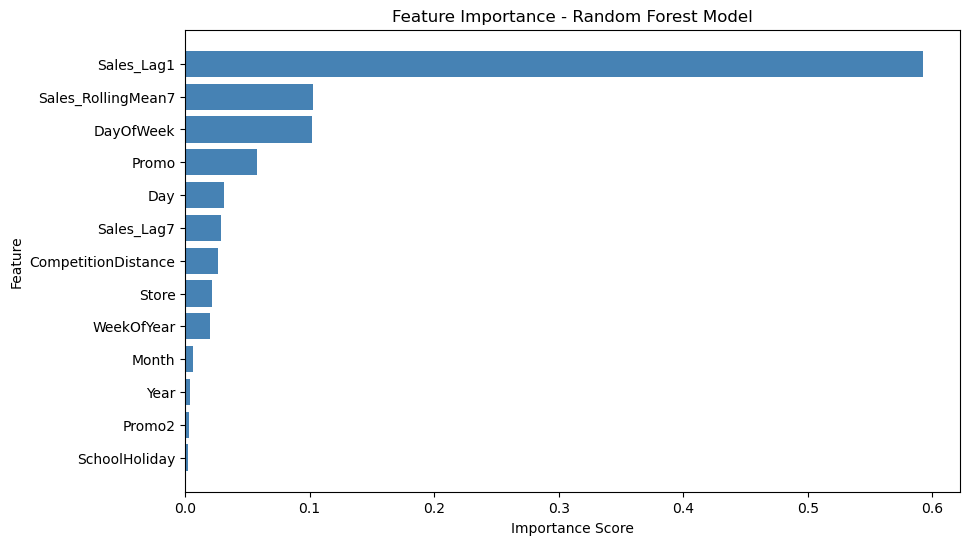

In [34]:
plt.figure(figsize=(10,6))
plt.barh(importance['Feature'], importance['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Feature Importance - Random Forest Model')
plt.gca().invert_yaxis()  
plt.show()